# IMPORT LIBRARIES


In [1]:
import pandas as pd
import numpy as np

## 1.1 Basic information

In [2]:
df = pd.read_csv('../data/creditcard.csv')
print("=== BASIC INFORMATION ===")
print(f"Data have {df.shape[0]} rows and {df.shape[1]} columns")
print(f"\nColumns name: \n{df.columns}")
print(f"\nDatatype of column \n{df.dtypes}")
print(f"\nFive first rows: \n{df.head().round(2)}")
print(f"\nDescriptive statistics \n{df.describe().round(2)}")

=== BASIC INFORMATION ===
Data have 284807 rows and 31 columns

Columns name: 
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Datatype of column 
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Five first rows: 
   Time    V1    V2    V3    V4    V5    V6 

# Data Overview: Credit Card Fraud Detection

---

### 1. Dataset Dimensions
<div style="background-color: #1c6fc2; padding: 15px; border-left: 5px solid #343a40;">
    <ul>
        <li><b>Total Observations:</b> 284,807 rows</li>
        <li><b>Total Features:</b> 31 columns</li>
        <li><b>Missing Values:</b> 0 (The dataset is complete with no null entries)</li>
    </ul>
</div>

### 2. Feature Composition

| Feature Group | Count | Data Type | Description |
| :--- | :---: | :---: | :--- |
| **PCA Components** (`V1` - `V28`) | 28 | `float64` | Transformed numerical features for privacy/anonymization. |
| **Metadata** (`Time`, `Amount`) | 2 | `float64` | Seconds elapsed since the first transaction and the transaction value. |
| **Target** (`Class`) | 1 | `int64` | Binary label (0: Legitimate, 1: Fraudulent). |

### 3. Key Statistical Observations

> **Initial Analysis:**

* **High Variance in Amount:** The `Amount` column shows a mean of $88.35$ but a standard deviation of $250.12$. The maximum value reaches $25,691.16$, indicating significant outliers.
* **Severe Class Imbalance:** The mean of the `Class` column is

## 1.2 Check missing values

In [3]:
missing_data = df.isnull().sum()
missing_percentage = missing_data / len(df) * 100
print(missing_data)
print(missing_percentage)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Time      0.0
V1        0.0
V2        0.0
V3        0.0
V4        0.0
V5        0.0
V6        0.0
V7        0.0
V8        0.0
V9        0.0
V10       0.0
V11       0.0
V12       0.0
V13       0.0
V14       0.0
V15       0.0
V16       0.0
V17       0.0
V18       0.0
V19       0.0
V20       0.0
V21       0.0
V22       0.0
V23       0.0
V24       0.0
V25       0.0
V26       0.0
V27       0.0
V28       0.0
Amount    0.0
Class     0.0
dtype: float64


**There is no missing value in dataset**

## 1.3 Check Duplicate value

In [4]:
duplicated_value = df.duplicated().sum()
duplicated_percentage = duplicated_value / len(df) * 100
print(f"Dataset have {duplicated_value} duplicated rows with {duplicated_percentage:.1f} percent")

Dataset have 1081 duplicated rows with 0.4 percent


### 4. Duplicate Value Treatment

A total of **1,081 duplicate rows** (~0.4%) were identified. These records were removed to ensure data quality and model reliability based on the following:

* **Statistical Impossibility:** Given the 15-decimal precision of PCA features ($V1$-$V28$), identical rows are likely logging errors rather than unique transactions.
* **Preventing Data Leakage:** Removing duplicates prevents the same observation from appearing in both training and testing sets, which would lead to over-optimistic (fake) performance metrics.
* **Model Generalization:** Eliminating redundant data points prevents the model from over-fitting to specific identical samples, ensuring it learns general patterns of fraud.

**Action taken:** `df.drop_duplicates(inplace=True)`

## Drop dulicated value 

In [5]:
df = df.drop_duplicates()
final_duplicates = df.duplicated().sum()

In [6]:
print(df.duplicated().sum())

0


# IMBALANCE HANDLE

## 2.1 Class Distribution Analysis

In [ ]:
imb_counts = df['Class'].value_counts()
imb_pct = df['Class'].value_counts(normalize=True) * 100
imb_rp = pd.DataFrame({"Count":imb_counts, "Percent" : imb_pct.round(2)})
print(f"Fraud (0): {imb_counts[0]} - {imb_pct[0]:.1f}%")
print(f"Fraud (1): {imb_counts[1]} - {imb_pct[1]:.1f}%")
print(imb_rp)


Fraud (0): 283253 - 99.8 %
Fraud (1): 473 - 0.2 %
        Count  Percent
Class                 
0      283253    99.83
1         473     0.17


In [14]:
FOLDER_NAME = '../plots_output' 
FILE_NAME = 'class_distribution_log.png' 

Created folder: '../plots_output'
Successfully saved plot to: '../plots_output\class_distribution_log.png'


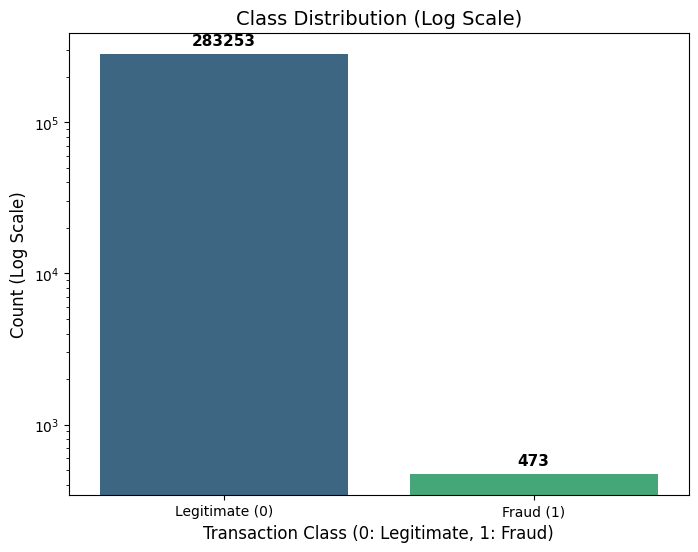

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

if not os.path.exists(FOLDER_NAME):
    os.makedirs(FOLDER_NAME)
    print(f"Created folder: '{FOLDER_NAME}'")

plt.figure(figsize=(8,6))

ax = sns.countplot(
    data = df,
    x = 'Class',
    hue = 'Class',
    palette='viridis',
    legend = False
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.yscale('log')

plt.title('Class Distribution (Log Scale)', fontsize=14)
plt.xlabel('Transaction Class (0: Legitimate, 1: Fraud)', fontsize=12)
plt.ylabel('Count (Log Scale)', fontsize=12)
plt.xticks([0, 1], ['Legitimate (0)', 'Fraud (1)'])

save_path = os.path.join(FOLDER_NAME, FILE_NAME)
plt.savefig(save_path, dpi=300, bbox_inches='tight') 

print(f"Successfully saved plot to: '{save_path}'")

plt.show()

### 2.1 Class Distribution Analysis

Due to the extreme imbalance in the dataset (Fraud cases are < 0.2%), a standard linear scale makes the fraud class invisible. 

* **Logarithmic Scaling:** We applied a log scale to the Y-axis to visualize both classes effectively.
* **Data Integrity:** Even after removing duplicates, the minority class (Fraud) remains significantly smaller, confirming the need for specialized sampling techniques (like SMOTE) later.
* **Observation:** Legitimate transactions dominate the dataset, which is typical for real-world fraud detection scenarios.

### 2.2 Discussion on Evaluation Metrics

#### 1. The Accuracy Trap
If a naive model predicts everything as **Class 0 (Legitimate)**, its accuracy would be:
$$Accuracy = \frac{Non\text{-}Fraud\ samples}{Total\ samples} \approx 99.83\%$$
Despite the high score, the model is **useless** because it fails to detect a single fraudulent transaction.

#### 2. False Negative (FN) vs. False Positive (FP)
In Fraud Detection, **False Negatives** (failing to catch a real fraud) are significantly more damaging:
* **For the Bank:** Direct financial loss and potential legal/regulatory penalties.
* **For the Customer:** Loss of funds and a feeling of insecurity.
* *Note:* While **False Positives** (blocking a legitimate card) cause customer annoyance, they are a manageable operational cost compared to the total loss from successful fraud.

#### 3. Selection of Optimal Metrics
Given the extreme class imbalance, we prioritize:
* **Recall:** To ensure we catch as many fraud cases as possible (minimize FN).
* **F1-Score:** To maintain a balance between catching fraud and not blocking too many innocent customers.
* **AUC-PR (Area Under Precision-Recall Curve):** This is often **superior to AUC-ROC** for imbalanced data because it focuses on the performance of the minority class (Fraud) rather than the majority class.
* **AUC-ROC:** While widely used, it can be misleadingly high in imbalanced datasets because the large number of legitimate transactions (Class 0) masks the model's failures on the fraud class (Class 1).

**Decision:** We will use **AUC-PR** as the primary metric to optimize our model, as it directly reflects the bank's goal: Catching fraud without harassing innocent customers.